##Binomial

In [19]:
import math
import pandas as pd
import seaborn as sns

In [39]:
class Binomial:
  win_probability: float
  n: int

  def __init__(self, wp: float, n: int):
    self.win_probability = wp
    self.n = n

  def P(self, X: int):
    loss_probability = 1 - self.win_probability
    probability = self.win_probability ** X * loss_probability ** (self.n - X)
    num_combinations = math.factorial(self.n) / (math.factorial(X) * (math.factorial(self.n - X)))
    probability = num_combinations * probability
    return probability

In [40]:
football_wins = Binomial(wp= 0.5, n=5)

In [44]:
football_wins.P(X=5)

0.03125

In [42]:
probabilities = []
for x in [0, 1, 2, 3, 4, 5]:
  p = football_wins.P(X=x)
  probabilities.append({"X": x, "p": p})

<Axes: xlabel='X', ylabel='p'>

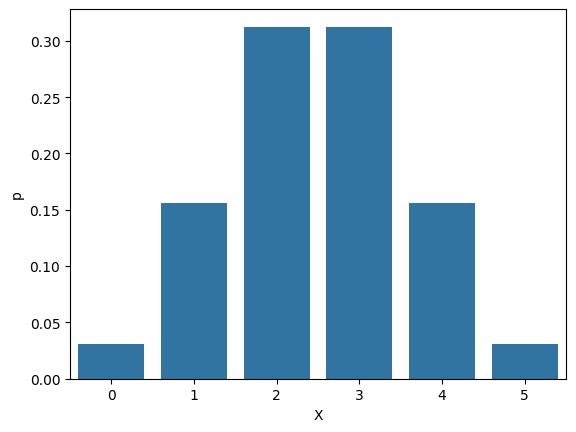

In [43]:
p_df = pd.DataFrame(probabilities)
sns.barplot(p_df, x="X", y="p")

##Increasing the trials

<Axes: xlabel='X', ylabel='p'>

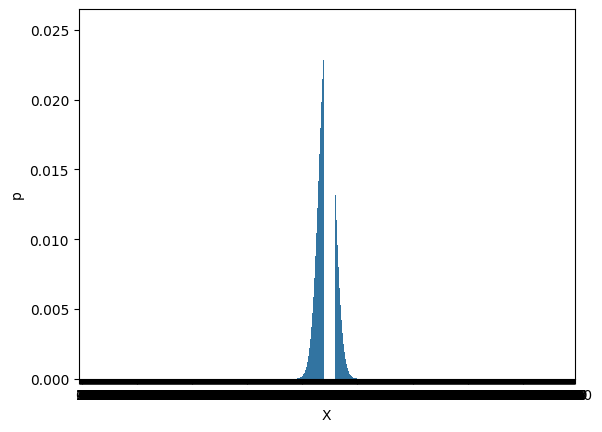

In [47]:
N_TRIALS = 1000
football_wins = Binomial(wp=0.5, n=N_TRIALS)
probabilities = []

for x in range(0, N_TRIALS + 1):
  p = football_wins.P(X=x)
  probabilities.append({"X": x, "p": p})
p_df = pd.DataFrame(probabilities)

sns.barplot(p_df, x="X", y="p")

##Central Limit Theorem

In [48]:
class CentralLimitTheorem:
  data: pd.DataFrame

  def __init__(self, url, column):
    self.data = pd.read_csv(url)
    self.data = self.data[column]

  def central_limit_plot(self, n_samples: int, sample_size: int):
    # Create the samples
    averages = []
    for i in range(0, n_samples + 1):
      average = self.data.sample(n=sample_size).mean()
      averages.append({"i": i, "avg": average})
    central_limit_df = pd.DataFrame(averages)
    print(central_limit_df)
    sns.histplot(central_limit_df, x="avg", kde=True)

In [49]:
clt = CentralLimitTheorem(url="https://data360files.worldbank.org/data360-data/data/WB_HCP/WB_HCP_TEST.csv", column="OBS_VALUE")

             i         avg
0            0  435.559726
1            1  451.910885
2            2  434.853184
3            3  435.689536
4            4  433.335145
...        ...         ...
99996    99996  435.945751
99997    99997  427.993986
99998    99998  408.324663
99999    99999  431.329878
100000  100000  425.297718

[100001 rows x 2 columns]


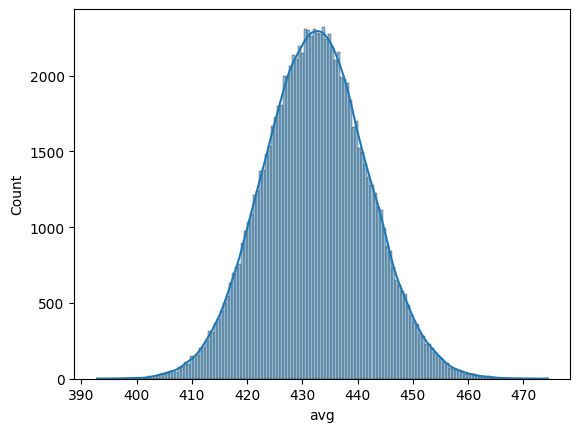

In [52]:
clt.central_limit_plot(100_000,50)

##Capstone work session